In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, utils

from torch.amp import autocast, GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
DATASET_PATH = "/kaggle/input/datasets/jackemartin/pokemon-sprites/pokemon_images"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Lambda(lambda img: img.convert("RGB")),  
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3) #[-1,1]
])

dataset = datasets.ImageFolder(root=DATASET_PATH, transform=transform)

BATCH_SIZE = 64

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Dataset size:", len(dataset))

Dataset size: 33887


In [3]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, 4, 1, 0)
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [4]:
z_dim = 100

G = Generator(z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()

lr = 0.0002

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

scaler_G = GradScaler(device='cuda')
scaler_D = GradScaler(device='cuda')

In [ ]:
EPOCHS = 30
SAVE_PATH = "/kaggle/working/"


G_losses_dcgan = []
D_losses_dcgan = []

if os.path.exists(SAVE_PATH + "G_dcgan_final.pth"):
    print("Loading saved DCGAN model...")
    G.load_state_dict(torch.load(SAVE_PATH + "G_dcgan_final.pth"))
    G.eval()
else:
    for epoch in range(EPOCHS):
        loop = tqdm(dataloader)

        for real, _ in loop:
            real = real.to(device)
            batch_size = real.size(0)

            noise = torch.randn(batch_size, z_dim, 1, 1).to(device)

            with autocast(device_type='cuda'):
                fake = G(noise)

                D_real = D(real)
                D_fake = D(fake.detach())

                loss_D = (
                    criterion(D_real, torch.ones_like(D_real)) +
                    criterion(D_fake, torch.zeros_like(D_fake))
                ) / 2

            opt_D.zero_grad()
            scaler_D.scale(loss_D).backward()
            scaler_D.step(opt_D)
            scaler_D.update()

            # Train Generator
            with autocast(device_type='cuda'):
                output = D(fake)
                loss_G = criterion(output, torch.ones_like(output))

            opt_G.zero_grad()
            scaler_G.scale(loss_G).backward()
            scaler_G.step(opt_G)
            scaler_G.update()

            G_losses_dcgan.append(loss_G.item())
            D_losses_dcgan.append(loss_D.item())

            loop.set_postfix(loss_D=loss_D.item(), loss_G=loss_G.item())

        if epoch % 5 == 0:
            torch.save(G.state_dict(), SAVE_PATH + f"G_dcgan_{epoch}.pth")

    torch.save(G.state_dict(), SAVE_PATH + "G_dcgan_final.pth")

  1%|          | 4/530 [00:02<03:41,  2.38it/s, loss_D=0.188, loss_G=5.43]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  2%|▏         | 12/530 [00:04<02:23,  3.60it/s, loss_D=0.0663, loss_G=7.77]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  0%|          | 0/530 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  0%|          | 0/530 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarni

In [7]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128, affine=True),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256, affine=True),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.InstanceNorm2d(512, affine=True),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, 4, 1, 0)
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [8]:
def gradient_penalty(critic, real, fake):
    batch_size, C, H, W = real.shape
    epsilon = torch.rand((batch_size, 1, 1, 1)).to(device)

    interpolated = real * epsilon + fake * (1 - epsilon)
    interpolated.requires_grad_(True)

    mixed_scores = critic(interpolated)

    gradient = torch.autograd.grad(
        inputs=interpolated,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True
    )[0]

    gradient = gradient.view(gradient.shape[0], -1)
    return ((gradient.norm(2, dim=1) - 1) ** 2).mean()

In [9]:
G_wgan = Generator(z_dim).to(device)
C = Critic().to(device)

opt_G_wgan = optim.Adam(G_wgan.parameters(), lr=lr, betas=(0.5, 0.999))
opt_C = optim.Adam(C.parameters(), lr=lr, betas=(0.5, 0.999))

lambda_gp = 10
critic_iters = 5

if os.path.exists(SAVE_PATH + "G_wgan_final.pth"):
    print("Loading saved WGAN model...")
    G_wgan.load_state_dict(torch.load(SAVE_PATH + "G_wgan_final.pth"))
    G_wgan.eval()
else:
    for epoch in range(EPOCHS):
        loop = tqdm(dataloader)

        for real, _ in loop:
            real = real.to(device)
            batch_size = real.size(0)

            for _ in range(critic_iters):
                noise = torch.randn(batch_size, z_dim, 1, 1).to(device)

                with autocast(device_type='cuda'):
                    fake = G_wgan(noise)

                    critic_real = C(real)
                    critic_fake = C(fake.detach())

                    gp = gradient_penalty(C, real, fake)

                    loss_C = -(torch.mean(critic_real) - torch.mean(critic_fake)) + lambda_gp * gp

                opt_C.zero_grad()
                scaler_D.scale(loss_C).backward()
                scaler_D.step(opt_C)
                scaler_D.update()

            noise = torch.randn(batch_size, z_dim, 1, 1).to(device)

            with autocast(device_type='cuda'):
                fake = G_wgan(noise)
                loss_G = -torch.mean(C(fake))

            opt_G_wgan.zero_grad()
            scaler_G.scale(loss_G).backward()
            scaler_G.step(opt_G_wgan)
            scaler_G.update()

        if epoch % 5 == 0:
            torch.save(G_wgan.state_dict(), SAVE_PATH + f"G_wgan_{epoch}.pth")

    torch.save(G_wgan.state_dict(), SAVE_PATH + "G_wgan_final.pth")

  0%|          | 0/530 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  0%|          | 0/530 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  0%|          | 0/530 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  0

In [10]:
def show_images(model, title):
    model.eval()

    noise = torch.randn(16, z_dim, 1, 1).to(device)

    with torch.no_grad():
        fake = model(noise).cpu()

    grid = utils.make_grid(fake, normalize=True)

    plt.figure(figsize=(6,6))
    plt.title(title)
    plt.imshow(np.transpose(grid, (1,2,0)))
    plt.axis("off")
    plt.show()

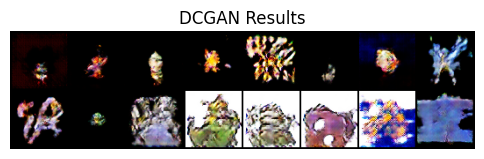

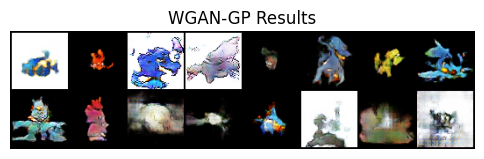

In [11]:
# Ensure models exist (fix for NameError)
if 'G' not in globals():
    G = Generator(z_dim).to(device)
    G.load_state_dict(torch.load(SAVE_PATH + "G_dcgan_final.pth"))

if 'G_wgan' not in globals():
    G_wgan = Generator(z_dim).to(device)
    G_wgan.load_state_dict(torch.load(SAVE_PATH + "G_wgan_final.pth"))

show_images(G, "DCGAN Results")
show_images(G_wgan, "WGAN-GP Results")

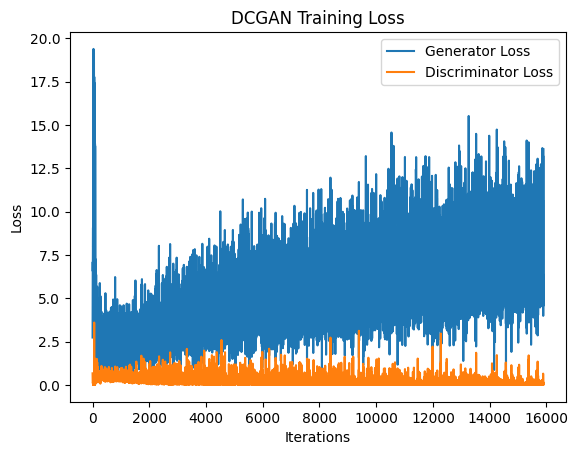

NameError: name 'G_losses_wgan' is not defined

<Figure size 640x480 with 0 Axes>

In [12]:

plt.figure()
plt.plot(G_losses_dcgan, label="Generator Loss")
plt.plot(D_losses_dcgan, label="Discriminator Loss")
plt.title("DCGAN Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()


plt.figure()
plt.plot(G_losses_wgan, label="Generator Loss")
plt.plot(C_losses_wgan, label="Critic Loss")
plt.title("WGAN-GP Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()